# Imports and load data
This notebook contains the changes in the intra-family minimum structural distance produced by each subsampling strategy.

In [6]:
import pandas as pd
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [7]:
DISTANCE_PATH = Path("../data/ArchiveII_distances.h5") 
SUBSAMPLED_PATH = Path("../results/ArchiveII_subsampled_ids.csv") 

families = [ "5s", "tRNA", "tmRNA", "RNaseP", "srp", "telomerase", "grp1", "23s", "16s"] 
distances = pd.read_hdf(DISTANCE_PATH, key='rnadist')
# normalize between 0 and 1
distances /= distances.max().max()


df_ids = pd.read_csv(SUBSAMPLED_PATH)
df_ids["fam"] = df_ids["id"].str.split("_").str[0]
splits = df_ids["partition"].unique()
ids = {}
for split in splits:
    ids[split] = {}
    df_split = df_ids.loc[df_ids["partition"] == split, ["id", "fam"]]

    # ids corresponding to each family in the current split
    for fam in families:
        ids[split][fam] = df_split.loc[df_split["fam"] == fam, "id"].to_numpy()

# Data processing and functions to plot

In [ ]:
def prepare_intra_distances(ids, distances, families_order, n_order):
    rows = []

    for partition, fam_dict in ids.items():
        if partition == "full":
            continue

        strategy, n = partition.split("S")
        strategy += "S"
        n = int(n)

        if n not in n_order:
            continue

        for family in families_order:
            family_ids = fam_dict[family]
            matrix = distances.loc[family_ids, family_ids].to_numpy()
            values = matrix[~np.eye(len(matrix), dtype=bool)]

            for metric, value in [
                ("Min", values.min()),
                ("Mean", values.mean()),
            ]:
                rows.append({
                    "family": family,
                    "distance": value,
                    "metric": metric,
                    "n": n,
                    "strategy": strategy,
                })

    data = pd.DataFrame(rows)

    step = len(n_order) + 1
    x_positions = {
        (family, n): i * step + j
        for i, family in enumerate(families_order)
        for j, n in enumerate(n_order)
    }

    data["x_pos"] = [
        x_positions[family, n]
        for family, n in zip(data["family"], data["n"])
    ]

    all_x = list(x_positions.values())
    family_centers = [
        i * step + (len(n_order) - 1) / 2
        for i in range(len(families_order))
    ]

    return data, all_x, family_centers

In [ ]:

def plot_strategy(ax, data, strategy, color, families_order):
    sub = data[
        (data["metric"] == "Min") &
        (data["strategy"] == strategy)
    ]

    for family in families_order:
        family_data = (
            sub[sub["family"] == family]
            .sort_values("x_pos")
        )

        ax.plot(
            family_data["x_pos"],
            family_data["distance"],
            color=color,
            linewidth=1,
            alpha=0.45,
        )

    ax.scatter(
        sub["x_pos"],
        sub["distance"],
        color=color,
        s=42,
        alpha=0.65,
    )


def plot_intra_distances(ids, distances, families_order, n_order):
    strategies = ["randS", "sortS", "clusS"]
    colors = dict(zip(strategies, plt.cm.tab10.colors))

    data, all_x, family_centers = prepare_intra_distances(
        ids, distances, families_order, n_order
    )

    fig, ax = plt.subplots(figsize=(8, 8))

    for strategy in strategies:
        plot_strategy(
            ax, data, strategy, colors[strategy], families_order
        )

    ax.set_xticks(all_x)
    ax.set_xticklabels(
        [str(n) for _ in families_order for n in n_order],
        fontsize=10,
    )
    ax.set_xlabel("Maximum size per family (K)", fontsize=13)
    ax.set_ylabel("Structural distance", fontsize=13)
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(family_centers)
    ax_top.set_xticklabels(families_order, fontsize=12)

    handles = [
        Line2D(
            [], [], color="black", marker="o", linestyle="",
            label="Minimum structural distance",
        ),
        *[
            Line2D([], [], color=colors[s], label=s)
            for s in strategies
        ],
    ]

    ax.legend(
        handles=handles,
        loc="upper left",
        fontsize=10,
        frameon=False,
    )

    plt.tight_layout()
    return fig, ax, data

# Minimum structural distance per strategy

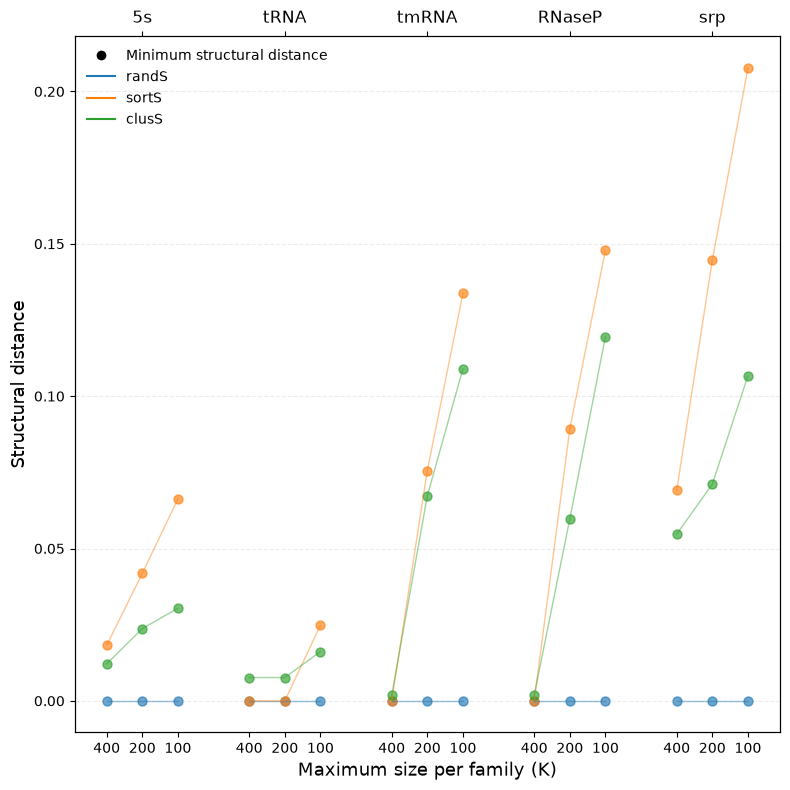

In [11]:
families_order = ["5s", "tRNA", "tmRNA", "RNaseP", "srp"]
n_order = [400, 200, 100]

fig, ax, long_df = plot_intra_distances(
    ids,
    distances,
    families_order,
    n_order,
)

plt.show()